<a href="https://colab.research.google.com/github/chrishan-92/ComputerVisionAssignment01/blob/Master/Comp_VIsion_Assigment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3143018987.py:85: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out, mode="L").save(output_path)


✅ Saved: /content/drive/MyDrive/Computer Vision/Assignment 1/emma_transformed.jpg


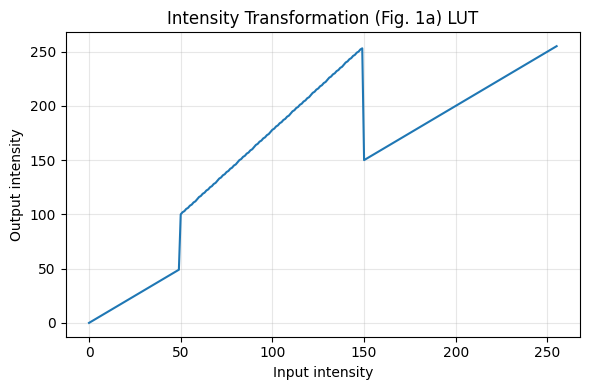

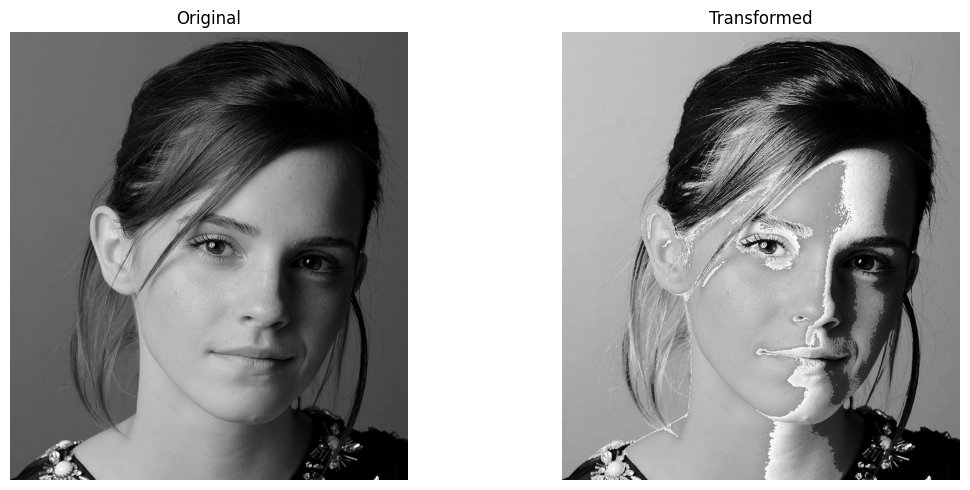

In [5]:
"""
Intensity transform (Fig. 1a) with a lookup table (LUT).

- Reads a grayscale image
- Applies the piecewise intensity mapping via LUT
- Saves the transformed image
- Optionally plots the LUT and before/after images

Author: Basti (intermediate style)
"""

from __future__ import annotations
from pathlib import Path
from typing import Tuple, Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


# ------------------------- LUT (Fig. 1a) ------------------------- #
def build_fig1a_lut() -> np.ndarray:
    """
    Build a 256-length LUT for the Fig. 1a transform:
      - 0..49: identity
      - 50..149: linear ramp 50→100 up to 150→255 (slope ≈ 1.55)
      - 150..255: identity
    """
    lut = np.arange(256, dtype=np.float32)

    # Identity segments
    lut[:50] = np.arange(0, 50)
    lut[150:] = np.arange(150, 256)

    # Linear middle segment
    x_mid = np.arange(50, 150, dtype=np.float32)
    y_mid = 100.0 + 1.55 * (x_mid - 50.0)
    lut[50:150] = y_mid

    # Clip + cast to uint8
    return np.clip(np.rint(lut), 0, 255).astype(np.uint8)


# ------------------------- Core Transform ------------------------ #
def apply_lut_to_image(
    image_path: Path,
    output_path: Path,
    lut: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply a LUT to a grayscale image.

    Parameters
    ----------
    image_path : Path
        Input image path.
    output_path : Path
        Output path for transformed image.
    lut : np.ndarray | None
        256-length LUT. If None, uses Fig. 1a LUT.

    Returns
    -------
    (orig, transformed) : Tuple[np.ndarray, np.ndarray]
        Original and transformed image arrays (uint8).
    """
    if lut is None:
        lut = build_fig1a_lut()

    if lut.dtype != np.uint8 or lut.shape != (256,):
        raise ValueError("LUT must be a uint8 array of shape (256,)")

    if not image_path.exists():
        raise FileNotFoundError(f"Input image not found: {image_path}")

    # Open as grayscale
    with Image.open(image_path) as im:
        gray = im.convert("L")
        arr = np.asarray(gray, dtype=np.uint8)

    # Vectorized LUT mapping
    out = lut[arr]

    # Save result
    Image.fromarray(out, mode="L").save(output_path)

    return arr, out


# --------------------------- Plotting ---------------------------- #
def show_summary(lut: np.ndarray, orig: np.ndarray, trans: np.ndarray) -> None:
    """Quick plots for LUT and before/after images."""
    x = np.arange(256)

    # LUT curve
    plt.figure(figsize=(6, 4))
    plt.plot(x, lut)
    plt.grid(True, alpha=0.3)
    plt.title("Intensity Transformation (Fig. 1a) LUT")
    plt.xlabel("Input intensity")
    plt.ylabel("Output intensity")
    plt.tight_layout()
    plt.show()

    # Before/after
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig, cmap="gray", vmin=0, vmax=255)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(trans, cmap="gray", vmin=0, vmax=255)
    plt.title("Transformed")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# --------------------------- Entrypoint -------------------------- #
def main() -> None:
    # Adjust these paths as needed (Colab-friendly)
    in_path = Path("/content/drive/MyDrive/Computer Vision/Assignment 1/emma.jpg")
    out_path = in_path.with_name(f"{in_path.stem}_transformed{in_path.suffix}")

    lut = build_fig1a_lut()
    orig, trans = apply_lut_to_image(in_path, out_path, lut=lut)

    print(f"✅ Saved: {out_path}")
    show_summary(lut, orig, trans)


if __name__ == "__main__":
    main()


✅ Saved gray-matter accentuation  -> /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice_gray_acc.png
✅ Saved white-matter accentuation -> /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice_white_acc.png


/tmp/ipython-input-616751541.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr.astype(np.uint8), mode="L").save(path)


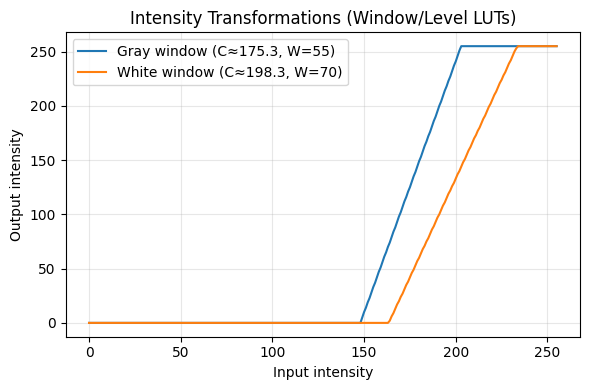

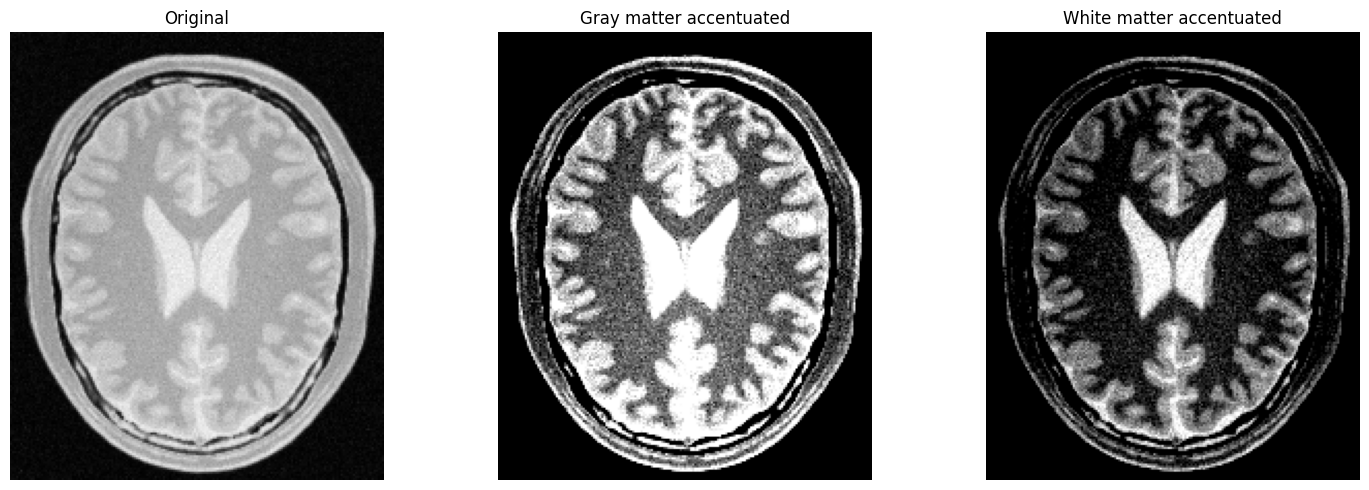

In [7]:
from __future__ import annotations
from pathlib import Path
from typing import Tuple
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


# --------------------- Core utils --------------------- #
def load_gray_u8(path: str | Path) -> np.ndarray:
    with Image.open(path) as im:
        return np.asarray(im.convert("L"), dtype=np.uint8)

def save_gray_u8(arr: np.ndarray, path: str | Path) -> None:
    Image.fromarray(arr.astype(np.uint8), mode="L").save(path)

def window_level_lut(center: float, width: float) -> np.ndarray:
    """
    Classic window/level mapping used in medical imaging.
      - center (L): intensity around which we keep most contrast
      - width  (W): band width that maps to 0..255 linearly
    """
    x = np.arange(256, dtype=np.float32)
    lo = center - width / 2.0
    hi = center + width / 2.0
    # piecewise-linear: below lo -> 0, above hi -> 255, linear in between
    y = (x - lo) * (255.0 / max(1.0, (hi - lo)))
    y = np.clip(y, 0, 255)
    return y.astype(np.uint8)

def apply_lut_u8(img: np.ndarray, lut: np.ndarray) -> np.ndarray:
    return lut[img]


# --------------------- Auto band selection --------------------- #
def auto_centers(img: np.ndarray) -> Tuple[float, float]:
    """
    Pick data-driven centers using percentiles:
      - gray matter  ≈ 60–70th percentile band center
      - white matter ≈ 80–90th percentile band center
    Tuned to typical PD-brain contrast (CSF < gray < white).
    """
    p = np.percentile(img, [60, 65, 70, 80, 85, 90]).astype(float)
    gray_center  = float(np.mean(p[0:3]))          # ~65th percentile
    white_center = float(np.mean(p[3:6]))          # ~85th percentile
    return gray_center, white_center


# ------------------------- Main ------------------------- #
def main() -> None:
    # Update path for your Colab/Drive setup
    in_path = Path("/content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice.png")
    out_gray  = in_path.with_name(f"{in_path.stem}_gray_acc.png")
    out_white = in_path.with_name(f"{in_path.stem}_white_acc.png")

    img = load_gray_u8(in_path)
    g_center, w_center = auto_centers(img)

    # Widths: gray a bit narrower, white slightly wider (tweakable)
    lut_gray  = window_level_lut(center=g_center, width=55)
    lut_white = window_level_lut(center=w_center, width=70)

    img_gray_acc  = apply_lut_u8(img, lut_gray)
    img_white_acc = apply_lut_u8(img, lut_white)

    save_gray_u8(img_gray_acc, out_gray)
    save_gray_u8(img_white_acc, out_white)
    print(f"✅ Saved gray-matter accentuation  -> {out_gray}")
    print(f"✅ Saved white-matter accentuation -> {out_white}")

    # ---------- Plots: transforms + results ---------- #
    x = np.arange(256)
    plt.figure(figsize=(6,4))
    plt.plot(x, lut_gray,  label=f"Gray window (C≈{g_center:.1f}, W=55)")
    plt.plot(x, lut_white, label=f"White window (C≈{w_center:.1f}, W=70)")
    plt.title("Intensity Transformations (Window/Level LUTs)")
    plt.xlabel("Input intensity")
    plt.ylabel("Output intensity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(img, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(img_gray_acc, cmap="gray", vmin=0, vmax=255); plt.title("Gray matter accentuated"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img_white_acc, cmap="gray", vmin=0, vmax=255); plt.title("White matter accentuated"); plt.axis("off")
    plt.tight_layout(); plt.show()


if __name__ == "__main__":
    main()

γ (gamma) used: 0.469


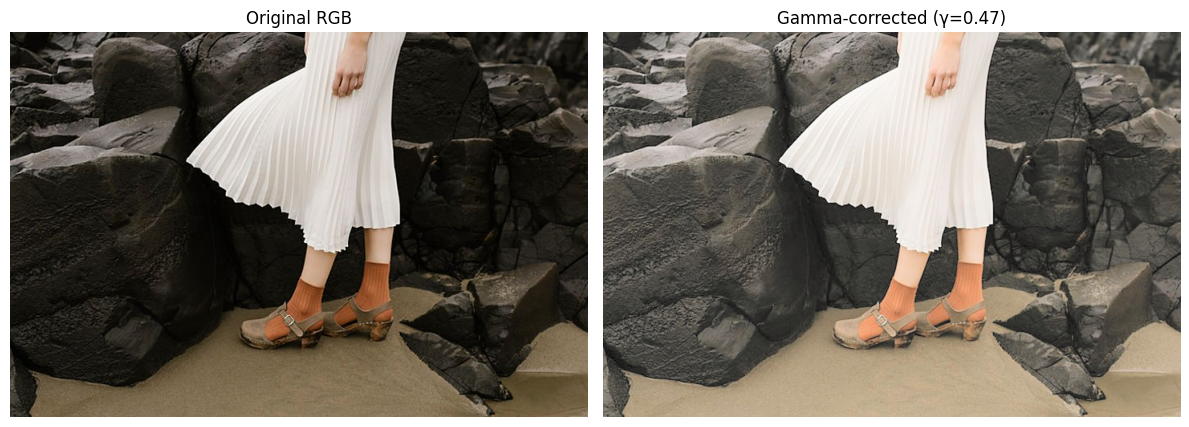

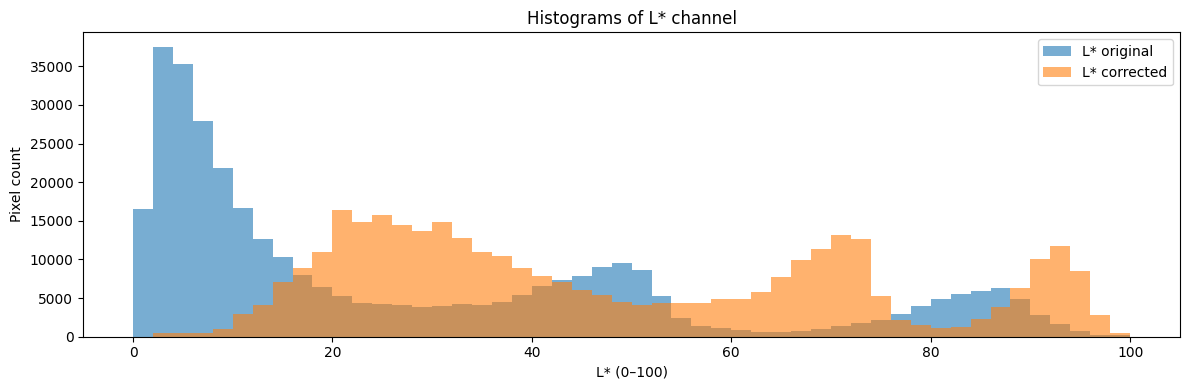

In [10]:
from __future__ import annotations
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_ubyte


# -------------------- Core ops -------------------- #
def rgb_to_lab(img_rgb: np.ndarray) -> np.ndarray:
    # skimage expects float in [0,1]
    return color.rgb2lab(np.clip(img_rgb / 255.0, 0, 1))

def lab_to_rgb8(lab: np.ndarray) -> np.ndarray:
    rgb = color.lab2rgb(lab)                       # float in [0,1]
    return img_as_ubyte(np.clip(rgb, 0, 1))        # uint8 [0,255]

def gamma_on_L(lab: np.ndarray, gamma: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply gamma to L* only. L* is in [0,100], so normalize to [0,1],
    do gamma, then scale back to [0,100].
    """
    L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
    Ln = np.clip(L / 100.0, 0, 1)
    L_corr = np.power(Ln, gamma)
    L_out = np.clip(L_corr * 100.0, 0, 100)
    lab_out = np.stack([L_out, a, b], axis=-1)
    return L, L_out, lab_out  # return original L*, corrected L*, and Lab image

def choose_gamma_auto(L: np.ndarray, target_mean: float = 0.5) -> float:
    """
    Pick a gamma so that mean(L_norm ** gamma) ~ target_mean.
    Solve: m**gamma = t  =>  gamma = log(t)/log(m)
    Falls back to 1.0 if degenerate.
    """
    m = float(np.clip(np.mean(L / 100.0), 1e-6, 1 - 1e-6))
    t = float(np.clip(target_mean, 1e-3, 1 - 1e-3))
    return np.log(t) / np.log(m)


# -------------------- Driver -------------------- #
def main() -> None:
    # Change to your path in Colab/Drive if needed
    in_path = Path("/content/drive/MyDrive/Computer Vision/Assignment 1/highlights_and_shadows.jpg")
    # demo image available in this session:
    # in_path = Path("/mnt/data/d023130c-fb4b-4c31-8d8e-cee4d27ba9db.png")

    img_rgb8 = io.imread(str(in_path))[:, :, :3]   # ensure RGB
    lab = rgb_to_lab(img_rgb8)

    # (A) Auto gamma to bring L* mean near 0.5
    gamma_auto = choose_gamma_auto(lab[..., 0], target_mean=0.55)

    # (B) Or fix it manually (e.g., brighten with 0.8, darken with 1.2)
    gamma = gamma_auto  # replace with 0.8 or 1.2 to force a value

    L_orig, L_corr, lab_corr = gamma_on_L(lab, gamma)
    img_corr = lab_to_rgb8(lab_corr)

    print(f"γ (gamma) used: {gamma:.3f}")

    # --------- Plots: images + L* histograms --------- #
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.imshow(img_rgb8); plt.title("Original RGB"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(img_corr);  plt.title(f"Gamma-corrected (γ={gamma:.2f})"); plt.axis("off")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(12,4))
    bins = np.linspace(0, 100, 51)
    plt.hist(L_orig.ravel(), bins=bins, alpha=0.6, label="L* original")
    plt.hist(L_corr.ravel(), bins=bins, alpha=0.6, label="L* corrected")
    plt.xlabel("L* (0–100)"); plt.ylabel("Pixel count"); plt.title("Histograms of L* channel")
    plt.legend(); plt.tight_layout(); plt.show()


if __name__ == "__main__":
    main()

✅ Saved vibrance-enhanced image: /content/drive/MyDrive/Computer Vision/Assignment 1/spider_vibrance.png
α used: 0.65, σ used: 70


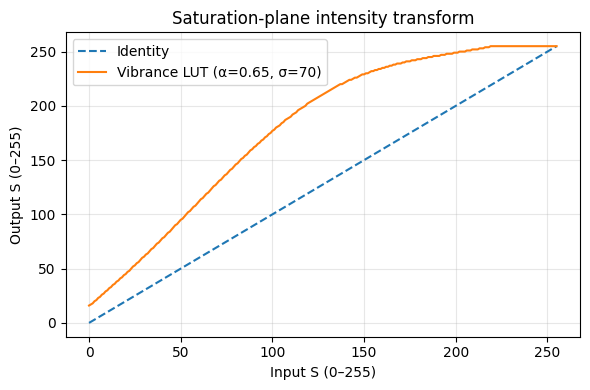

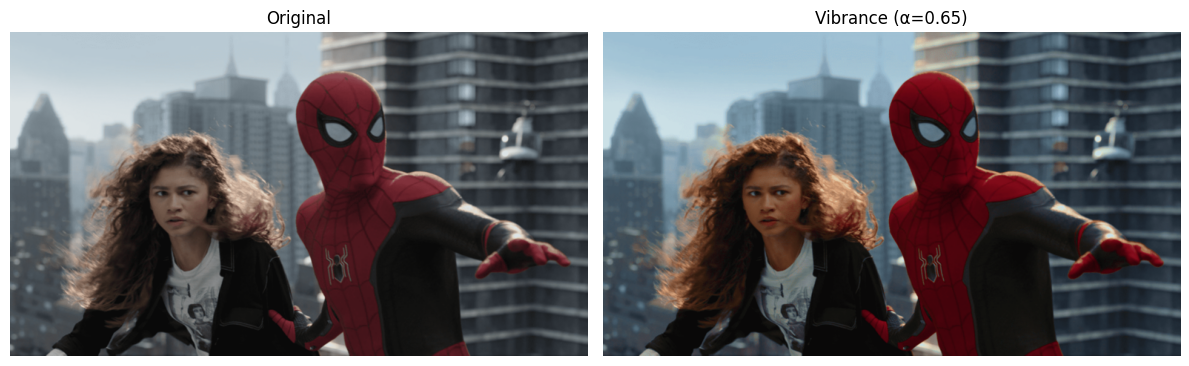

In [11]:

from __future__ import annotations
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_ubyte


# ----------------------- Transform ----------------------- #
def build_vibrance_lut(alpha: float, sigma: float = 70.0) -> np.ndarray:
    """
    Create a 256-entry LUT for the vibrance boost on saturation.
    x is saturation in [0..255].
    """
    x = np.arange(256, dtype=np.float32)
    boost = alpha * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * sigma ** 2))
    y = np.minimum(x + boost, 255.0)
    return np.rint(y).astype(np.uint8)

def enhance_vibrance_rgb(rgb_u8: np.ndarray, alpha: float, sigma: float = 70.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply vibrance LUT to S-plane of HSV image.
    Returns: (enhanced_rgb_u8, lut)
    """
    hsv = color.rgb2hsv(rgb_u8 / 255.0)  # float [0,1]
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    lut = build_vibrance_lut(alpha, sigma)
    S_u8 = np.rint(S * 255.0).astype(np.uint8)
    S_boost = lut[S_u8] / 255.0
    S_out = np.clip(S_boost, 0.0, 1.0)

    hsv_out = np.stack([H, S_out, V], axis=-1)
    rgb_out = img_as_ubyte(np.clip(color.hsv2rgb(hsv_out), 0, 1))
    return rgb_out, lut


# ------------------------ Demo/Plots ---------------------- #
def main() -> None:
    # Use your own path in Colab/Drive if needed:
    in_path = Path("/content/drive/MyDrive/Computer Vision/Assignment 1/spider.png")
    out_path = in_path.with_name(f"{in_path.stem}_vibrance.png")

    img = io.imread(str(in_path))[:, :, :3]  # RGB uint8
    alpha = 0.65                              # tweak until visually pleasing (report this)
    enhanced, lut = enhance_vibrance_rgb(img, alpha=alpha, sigma=70.0)

    io.imsave(str(out_path), enhanced)
    print(f"✅ Saved vibrance-enhanced image: {out_path}")
    print(f"α used: {alpha:.2f}, σ used: 70")

    # Plot the intensity transform on S-plane
    x = np.arange(256)
    plt.figure(figsize=(6, 4))
    plt.plot(x, x, "--", label="Identity")
    plt.plot(x, lut, label=f"Vibrance LUT (α={alpha:.2f}, σ=70)")
    plt.xlabel("Input S (0–255)"); plt.ylabel("Output S (0–255)")
    plt.title("Saturation-plane intensity transform")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

    # Show original vs enhanced
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1); plt.imshow(img);      plt.title("Original"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(enhanced); plt.title(f"Vibrance (α={alpha:.2f})"); plt.axis("off")
    plt.tight_layout(); plt.show()


if __name__ == "__main__":
    main()